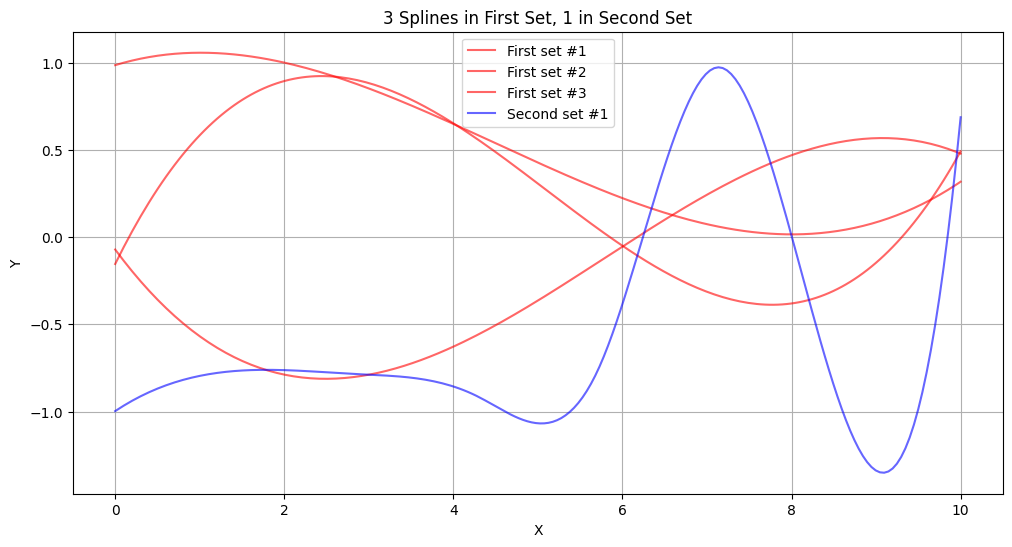

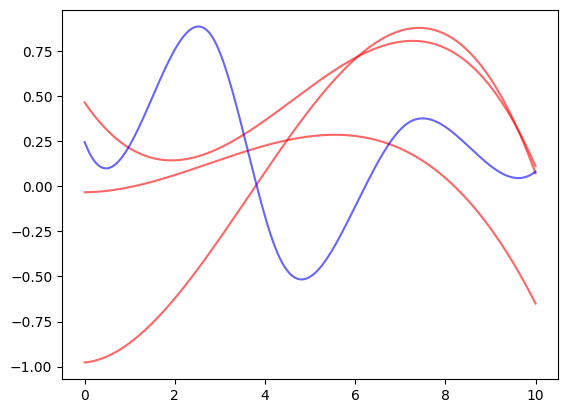

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Parameters: number of splines in each set
x_count = 3  # First set
y_count = 1  # Second set

# Common x-axis base
base_x = np.linspace(0, 10, 8)
base_x2 = np.linspace(0, 10, 4)
x_dense = np.linspace(0, 10, 200)

def generate_random_spline(x_points):
    """Generate a smooth spline from random y-values."""
    y_points = np.random.uniform(-1, 1, size=len(x_points))
    spline = make_interp_spline(x_points, y_points, k=3)
    return spline(x_dense)

# Plot setup
plt.figure(figsize=(12, 6))

# First set of splines (e.g., red)
for i in range(x_count):
    y_smooth = generate_random_spline(base_x2)
    plt.plot(x_dense, y_smooth, label=f'First set #{i+1}', color='red', alpha=0.6)

# Second set of splines (e.g., blue)
for j in range(y_count):
    y_smooth = generate_random_spline(base_x)
    plt.plot(x_dense, y_smooth, label=f'Second set #{j+1}', color='blue', alpha=0.6)

plt.title(f'{x_count} Splines in First Set, {y_count} in Second Set')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

first_set_points = [generate_random_spline(base_x2) for _ in range(x_count)]
second_set_points = [generate_random_spline(base_x) for _ in range(y_count)]

# Plot original splines
for i in range(x_count):
    plt.plot(x_dense, first_set_points[i], color='red', alpha=0.6, label=f'First set #{i+1}' if i == 0 else "")

for j in range(y_count):
    plt.plot(x_dense, second_set_points[j], color='blue', alpha=0.6, label=f'Second set #{j+1}' if j == 0 else "")



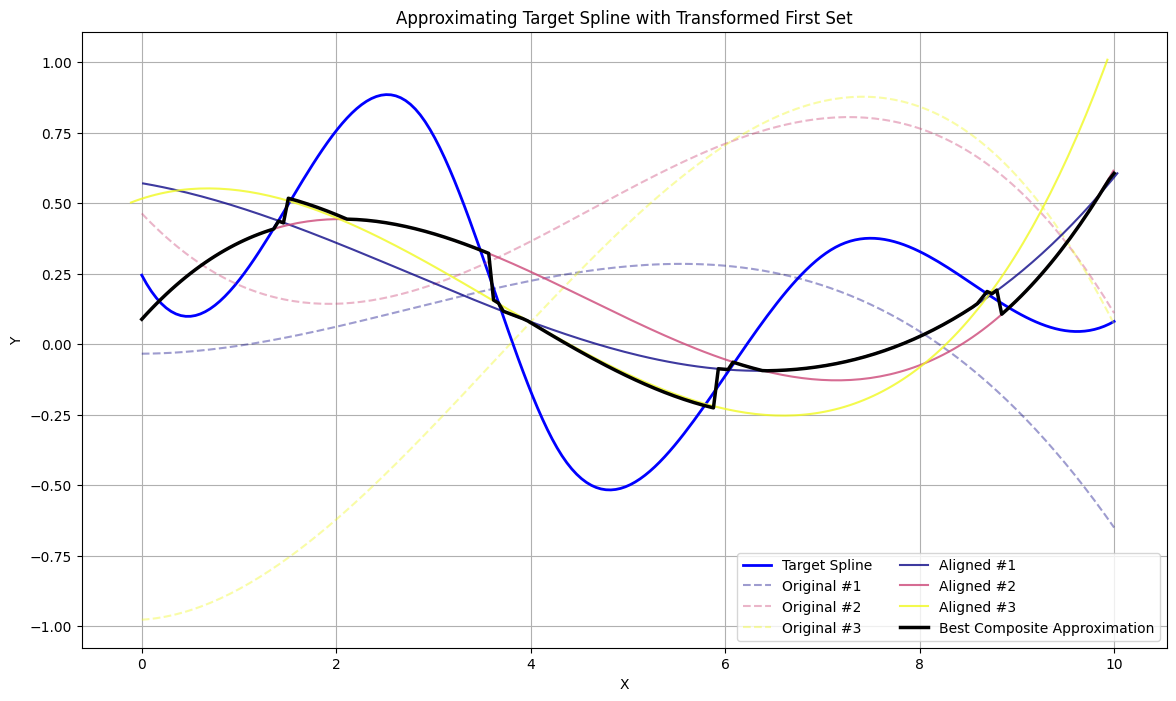

In [20]:
from scipy.spatial.transform import Rotation as R

# Target spline (first spline in the second set)
target_y = second_set_points[0]
target_pts = np.column_stack((x_dense, target_y))

# Step 1: Define alignment function (rotation + translation)
def align_spline(source_pts, target_pts):
    src_mean = np.mean(source_pts, axis=0)
    tgt_mean = np.mean(target_pts, axis=0)

    src_centered = source_pts - src_mean
    tgt_centered = target_pts - tgt_mean

    U, _, Vt = np.linalg.svd(tgt_centered.T @ src_centered)
    R_mat = U @ Vt

    aligned = (src_centered @ R_mat.T) + tgt_mean
    return aligned

# Step 2: Align each first-set spline to target
aligned_splines = []
for i in range(x_count):
    y = first_set_points[i]
    source_pts = np.column_stack((x_dense, y))
    aligned_pts = align_spline(source_pts, target_pts)
    aligned_splines.append(aligned_pts)

aligned_splines = np.array(aligned_splines)  # shape (x_count, len(x_dense), 2)

# Step 3: Find closest y at each x from the transformed splines
approximated_y = np.zeros_like(target_y)
responsible_spline_idx = np.zeros_like(target_y, dtype=int)

for i in range(len(x_dense)):
    candidates = aligned_splines[:, i, 1]  # y-values at this x
    target_val = target_y[i]

    distances = np.abs(candidates - target_val)
    best_idx = np.argmin(distances)

    approximated_y[i] = candidates[best_idx]
    responsible_spline_idx[i] = best_idx

# Step 4: Plot all stages
plt.figure(figsize=(14, 8))

# Target spline
plt.plot(x_dense, target_y, label='Target Spline', color='blue', linewidth=2)

# Original splines
colors = plt.cm.plasma(np.linspace(0, 1, x_count))
for i in range(x_count):
    plt.plot(x_dense, first_set_points[i], linestyle='--', color=colors[i], alpha=0.4, label=f'Original #{i+1}')

# Transformed splines
for i in range(x_count):
    plt.plot(aligned_splines[i, :, 0], aligned_splines[i, :, 1], color=colors[i], alpha=0.8, label=f'Aligned #{i+1}')

# Composite approximation
plt.plot(x_dense, approximated_y, color='black', linewidth=2.5, label='Best Composite Approximation')

plt.title("Approximating Target Spline with Transformed First Set")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(ncol=2)
plt.grid(True)
plt.show()
